In [14]:
import tensorflow as tf
import pathlib

data_dir = pathlib.Path('C:/Users/alisa/Documents/numbers-data')

img_height = 28
img_width = 28
batch_size = 32


train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size = (img_height,img_width),
    batch_size = batch_size,
    label_mode ='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size = (img_height,img_width),
    batch_size = batch_size,
    label_mode ='int'
)

class_names = train_ds.class_names
print("Classes found:", class_names)



Found 21555 files belonging to 10 classes.
Using 17244 files for training.
Found 21555 files belonging to 10 classes.
Using 4311 files for validation.
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [15]:
import tensorflow as tf
import numpy as np


normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

num_classes = len(class_names)


model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes) # Output layer with one node per class
])

model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=5
)
print("--- Model Training Finished ---")


print("\n--- Evaluating Model on Test Data ---")
loss, accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6593 - loss: 1.0551 - val_accuracy: 0.8692 - val_loss: 0.4301
Epoch 2/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9047 - loss: 0.3127 - val_accuracy: 0.9019 - val_loss: 0.3026
Epoch 3/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9428 - loss: 0.1940 - val_accuracy: 0.9348 - val_loss: 0.2134
Epoch 4/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.9582 - loss: 0.1350 - val_accuracy: 0.9390 - val_loss: 0.1949
Epoch 5/5
539/539 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.9682 - loss: 0.1012 - val_accuracy: 0.9404 - val_loss: 0.1946
--- Model Training Finished ---

--- Evaluating Model on Test Data ---
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9404 - loss: 0.1946

Test Loss: 0.1946
Test Accuracy: 0.9404


135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


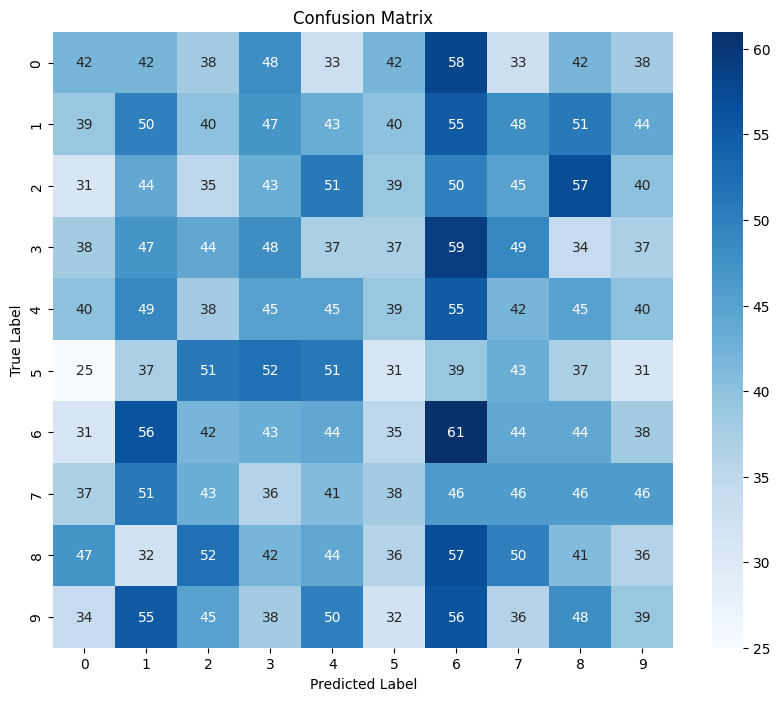

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1) 
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# --- 1. Generate and Plot the Confusion Matrix ---
conf_matrix = confusion_matrix(y_true, y_pred)


plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# print("\n--- Classification Report ---\n")
# print(classification_report(y_true, y_pred, target_names=class_names))